## Feature Engineering

### Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

sns.set_style("whitegrid")

os.makedirs("../visualizations", exist_ok=True)

### Load Dataset

In [2]:
df = pd.read_csv("../data/traffic_preprocessed.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (120000, 19)


,timestamp,hour,day_of_week,geohash_location,road_type,num_lanes,traffic_signals,large_vehicles_count,temperature,humidity,rainfall,weather_conditions,nearby_landmarks,traffic_demand,month,event_Concert,event_Conference,event_Festival,event_Sports_Event
0,2023-01-01 00:00:00,0,6,38,4,3,0.817106,-1.415303,-0.912469,0.113391,-0.338257,0,1,201.0,-1.34109,False,False,False,False
1,2023-01-01 00:05:00,0,6,28,0,5,-1.223831,0.706767,-0.927065,0.834313,-0.338257,0,7,965.0,-1.34109,False,False,True,False
2,2023-01-01 00:10:00,0,6,14,3,3,-1.223831,0.353089,-0.994952,-0.006479,-0.338257,0,7,322.0,-1.34109,False,False,False,False
3,2023-01-01 00:15:00,0,6,42,3,4,0.817106,0.706767,-1.580376,0.593531,-0.338257,0,6,419.0,-1.34109,False,False,False,False
4,2023-01-01 00:20:00,0,6,7,0,4,0.817106,-0.707946,-1.056254,-0.559013,-0.338257,0,0,448.0,-1.34109,False,False,False,False


### Peak Hour Flag

In [3]:
df["peak_hour_flag"] = np.where(
    ((df["hour"] >= 7) & (df["hour"] <= 9)) |
    ((df["hour"] >= 17) & (df["hour"] <= 19)),
    1,
    0
)

print(df["peak_hour_flag"].value_counts())

peak_hour_flag
0    90012
1    29988
Name: count, dtype: int64


### Weekend Flag

In [4]:
df["weekend_flag"] = np.where(
    df["day_of_week"] >= 5,
    1,
    0
)

print(df["weekend_flag"].value_counts())

weekend_flag
0    85728
1    34272
Name: count, dtype: int64


### Rush Hour Flag
Rush Hour = Peak Hour AND Weekday

In [5]:
df["rush_hour_indicator"] = np.where(
    (df["peak_hour_flag"] == 1) &
    (df["weekend_flag"] == 0),
    1,
    0
)

print(df["rush_hour_indicator"].value_counts())

rush_hour_indicator
0    98580
1    21420
Name: count, dtype: int64


### Traffic Signal Density

In [6]:
df["signal_density"] = df["traffic_signals"] / df["num_lanes"]

### Weather Impact Score

Weighted sum:<br>
Temperature - 0.4<br>
Humidity - 0.3<br>
Rainfall - 0.3<br>
Normalize between 0 and 1.

In [7]:
weather_score = (
      0.4 * df["temperature"]
    + 0.3 * df["humidity"]
    + 0.3 * df["rainfall"]
)

scaler = MinMaxScaler()

df["weather_impact_score"] = scaler.fit_transform(
    weather_score.values.reshape(-1,1)
)

### Traffic Density Score
Formula : ( ( LargeVehicle * 1.5 )+TrafficDemand ) / NumLanes

In [8]:
density = (
    (df["large_vehicles_count"]*1.5)
    + df["traffic_demand"]
) / df["num_lanes"]

df["traffic_density_score"] = scaler.fit_transform(
    density.values.reshape(-1,1)
)

### View New Features

In [9]:
new_features = [
    "peak_hour_flag",
    "weekend_flag",
    "rush_hour_indicator",
    "weather_impact_score",
    "traffic_density_score"
]

print(df[new_features].head())

   peak_hour_flag  weekend_flag  rush_hour_indicator  weather_impact_score  \
0               0             1                    0              0.247931   
1               0             1                    0              0.290970   
2               0             1                    0              0.233829   
3               0             1                    0              0.222750   
4               0             1                    0              0.194912   

   traffic_density_score  
0               0.040868  
1               0.146096  
2               0.075041  
3               0.072973  
4               0.078544  


### Correlation With Traffic Demand

In [10]:
corr = (
    df.corr(numeric_only=True)["traffic_demand"]
      .sort_values(ascending=False)
)

print(corr)

traffic_demand           1.000000
traffic_density_score    0.844499
rush_hour_indicator      0.647833
peak_hour_flag           0.518145
hour                     0.235369
event_Festival           0.139046
num_lanes                0.137884
event_Concert            0.098735
event_Conference         0.096543
event_Sports_Event       0.094198
large_vehicles_count     0.017458
geohash_location        -0.005343
month                   -0.007203
signal_density          -0.031138
traffic_signals         -0.033182
nearby_landmarks        -0.055164
temperature             -0.056353
rainfall                -0.072583
weather_conditions      -0.112213
day_of_week             -0.133070
weekend_flag            -0.169150
weather_impact_score    -0.186117
humidity                -0.213401
road_type               -0.218074
Name: traffic_demand, dtype: float64


### Random Forest (Feature Importance)

In [11]:
X = df.drop(columns=["traffic_demand"])

X = X.select_dtypes(include=np.number)

y = df["traffic_demand"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X,y)

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                  Feature    Importance
18  traffic_density_score  8.340587e-01
4               num_lanes  1.655573e-01
3               road_type  3.795812e-04
6    large_vehicles_count  3.327722e-06
2        geohash_location  1.425643e-07
7             temperature  1.344713e-07
8                humidity  1.315730e-07
17   weather_impact_score  1.273492e-07
12                  month  1.013220e-07
11       nearby_landmarks  9.039253e-08
0                    hour  8.852918e-08
1             day_of_week  8.145065e-08
16         signal_density  2.347030e-08
10     weather_conditions  2.044276e-08
9                rainfall  2.011216e-08


Bar Chart

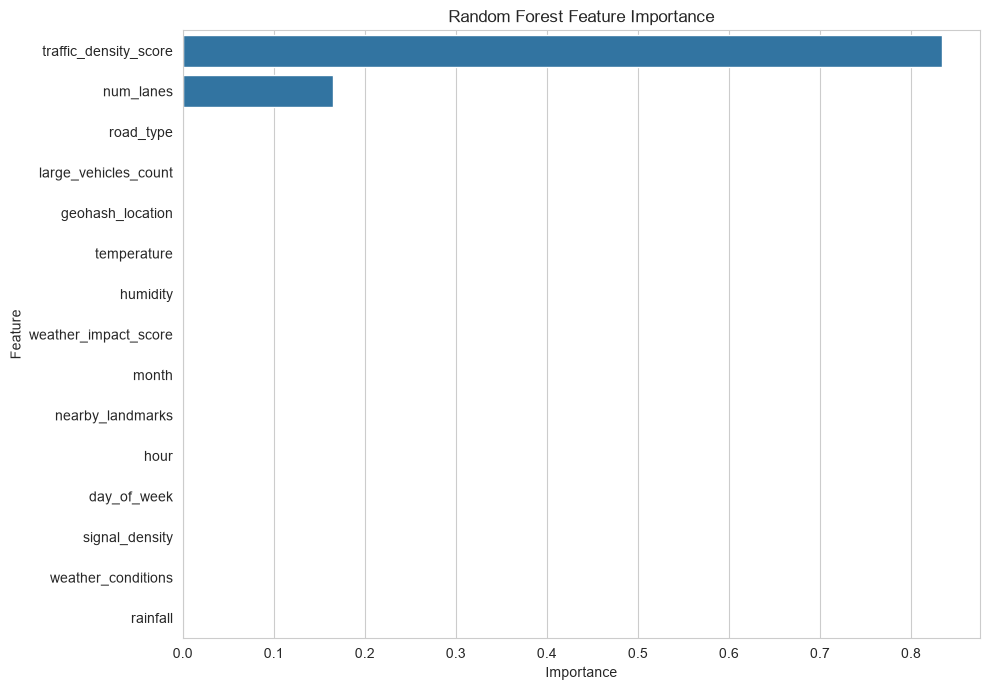

In [12]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()


plt.show()

### Feature Correlation Heatmap

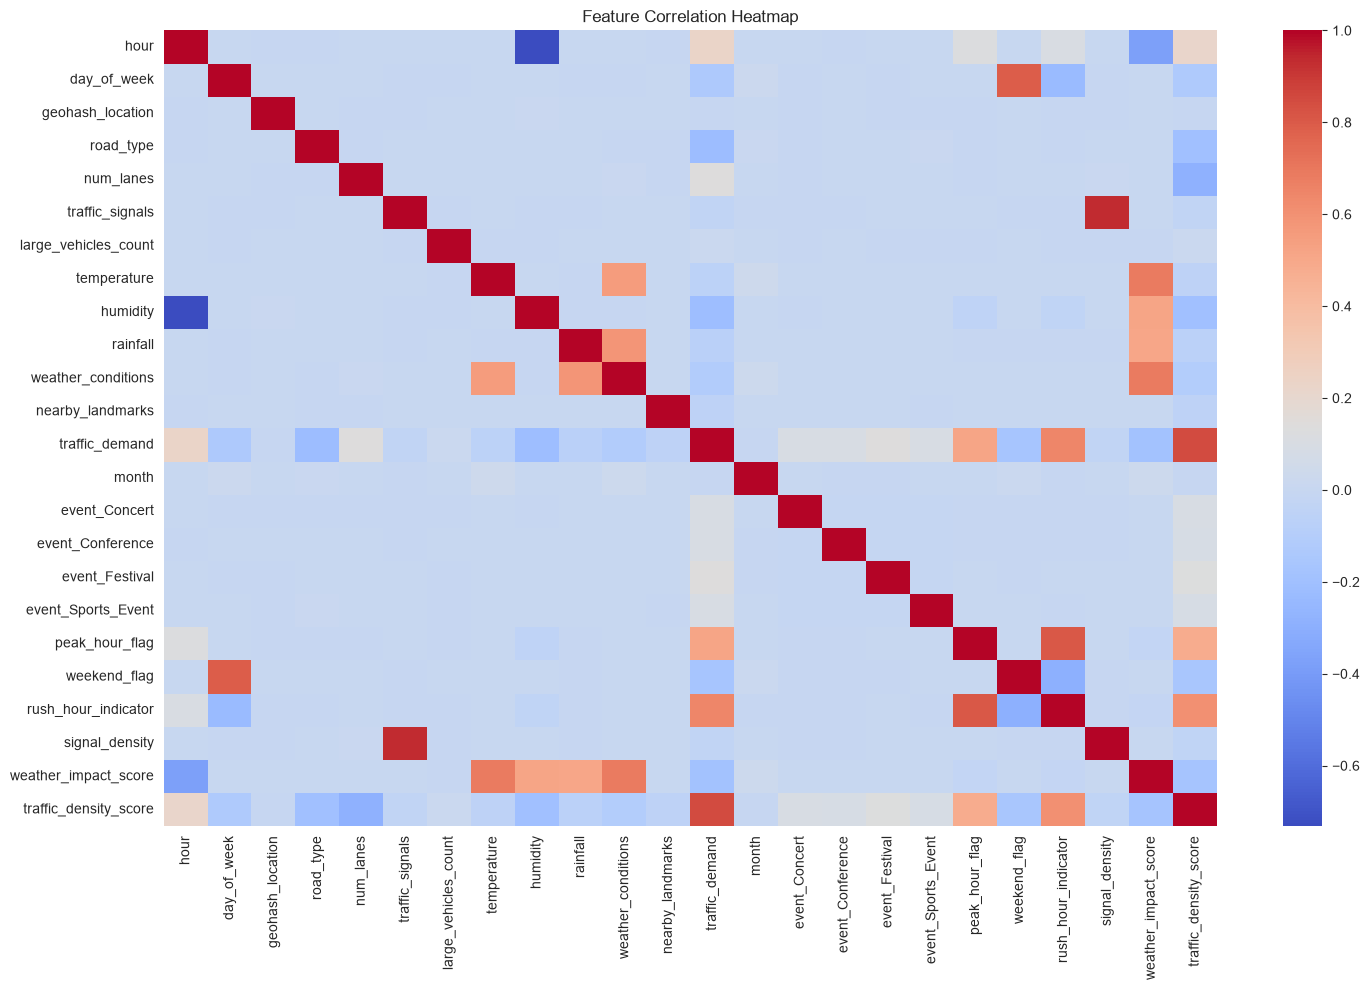

In [13]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../visualizations/06_feature_correlation_heatmap.png",
    dpi=300
)

plt.show()

In [14]:
df.to_csv(
    "../data/traffic_featured.csv",
    index=False
)
